# Codveda Data Analytics Internship - Level 2 (Intermediate)

- Task 1: Regression Analysis
- Task 2: Time Series Analysis
- Task 3: K-Means Clustering Analysis

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style="whitegrid", palette="Set2")

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("outputs/level_2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Task 1: Regression Analysis

In [2]:
# Load the house prediction dataset. The raw file is whitespace-separated and has no header row.
house_columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"
]
house = pd.read_csv(DATA_DIR / "house-prediction-dataset.csv", header=None, sep=r"\s+", names=house_columns)

# Convert every column to numeric and impute any parsing issues with the median.
for col in house.columns:
    house[col] = pd.to_numeric(house[col], errors="coerce")
house = house.fillna(house.median(numeric_only=True)).drop_duplicates().reset_index(drop=True)

print("House dataset shape:", house.shape)
house.head()

House dataset shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
# Simple linear regression: predict house value (MEDV) from average rooms (RM).
X = house[["RM"]]
y = house["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Coefficient for RM: {model.coef_[0]:.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"R-squared: {r2:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")

Coefficient for RM: 9.348
Intercept: -36.246
R-squared: 0.371
MSE: 46.145
RMSE: 6.793


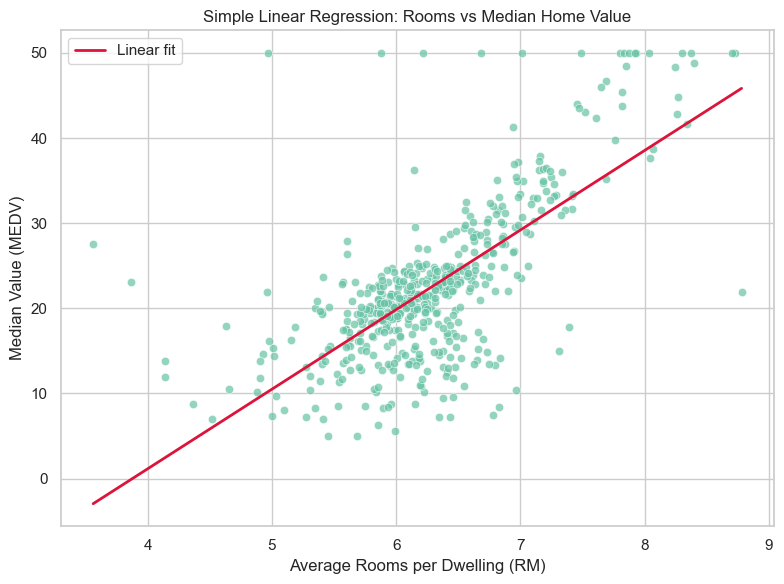

In [4]:
# Visualize the regression line on the full dataset.
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=house, x="RM", y="MEDV", alpha=0.7, ax=ax)
line_x = np.linspace(house["RM"].min(), house["RM"].max(), 100).reshape(-1, 1)
line_y = model.predict(pd.DataFrame(line_x, columns=["RM"]))
ax.plot(line_x, line_y, color="crimson", linewidth=2, label="Linear fit")
ax.set_title("Simple Linear Regression: Rooms vs Median Home Value")
ax.set_xlabel("Average Rooms per Dwelling (RM)")
ax.set_ylabel("Median Value (MEDV)")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "regression_rm_medv.png", dpi=150, bbox_inches="tight")
plt.show()

### Regression Interpretation

The coefficient shows the expected change in `MEDV` for one additional average room. A positive coefficient means homes with more rooms tend to have higher median values.

## Task 2: Time Series Analysis

In [5]:
# Load stock prices and focus on Apple (AAPL) for a clear single time series.
stocks = pd.read_csv(DATA_DIR / "2) Stock Prices Data Set.csv", parse_dates=["date"])
aapl = (
    stocks.loc[stocks["symbol"] == "AAPL", ["date", "close", "volume"]]
    .sort_values("date")
    .set_index("date")
)

# Convert business-day stock data to monthly averages for stable seasonality decomposition.
aapl_monthly = aapl["close"].resample("M").mean().dropna()

print("AAPL daily date range:", aapl.index.min().date(), "to", aapl.index.max().date())
print("Monthly observations:", len(aapl_monthly))
aapl_monthly.head()

AAPL daily date range: 2014-01-02 to 2017-12-29
Monthly observations: 48


C:\Users\Hewlett Packard\AppData\Local\Temp\ipykernel_8840\1124182166.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  aapl_monthly = aapl["close"].resample("M").mean().dropna()


date
2014-01-31    76.777876
2014-02-28    75.225637
2014-03-31    76.173400
2014-04-30    77.296243
2014-05-31    86.170752
Freq: ME, Name: close, dtype: float64

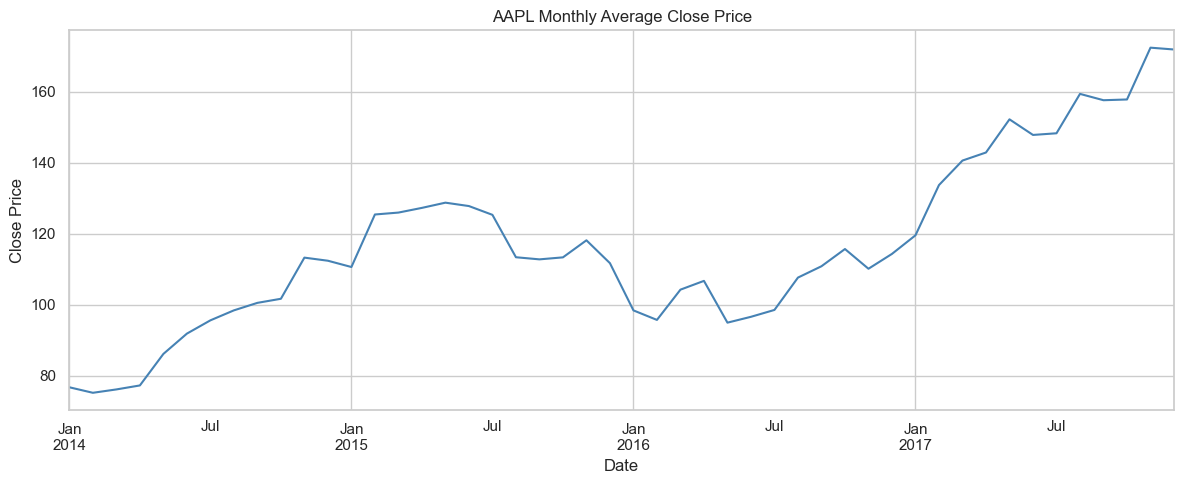

In [6]:
# Plot the monthly close price to identify the overall trend.
fig, ax = plt.subplots(figsize=(12, 5))
aapl_monthly.plot(ax=ax, color="steelblue")
ax.set_title("AAPL Monthly Average Close Price")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "aapl_monthly_close.png", dpi=150, bbox_inches="tight")
plt.show()

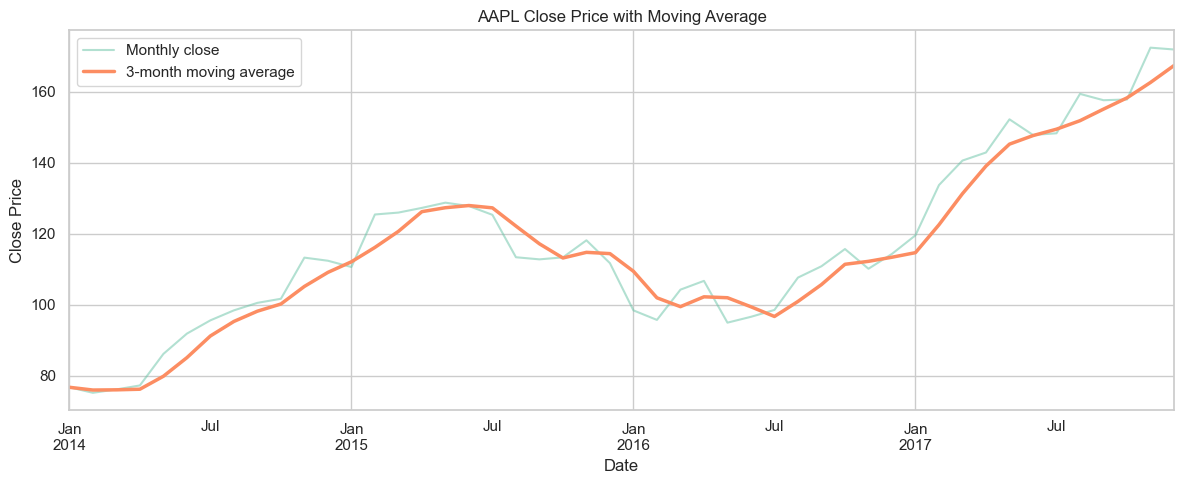

In [7]:
# Moving-average smoothing helps reveal the broader trend.
aapl_ma = aapl_monthly.rolling(window=3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))
aapl_monthly.plot(ax=ax, alpha=0.5, label="Monthly close")
aapl_ma.plot(ax=ax, linewidth=2.5, label="3-month moving average")
ax.set_title("AAPL Close Price with Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "aapl_moving_average.png", dpi=150, bbox_inches="tight")
plt.show()

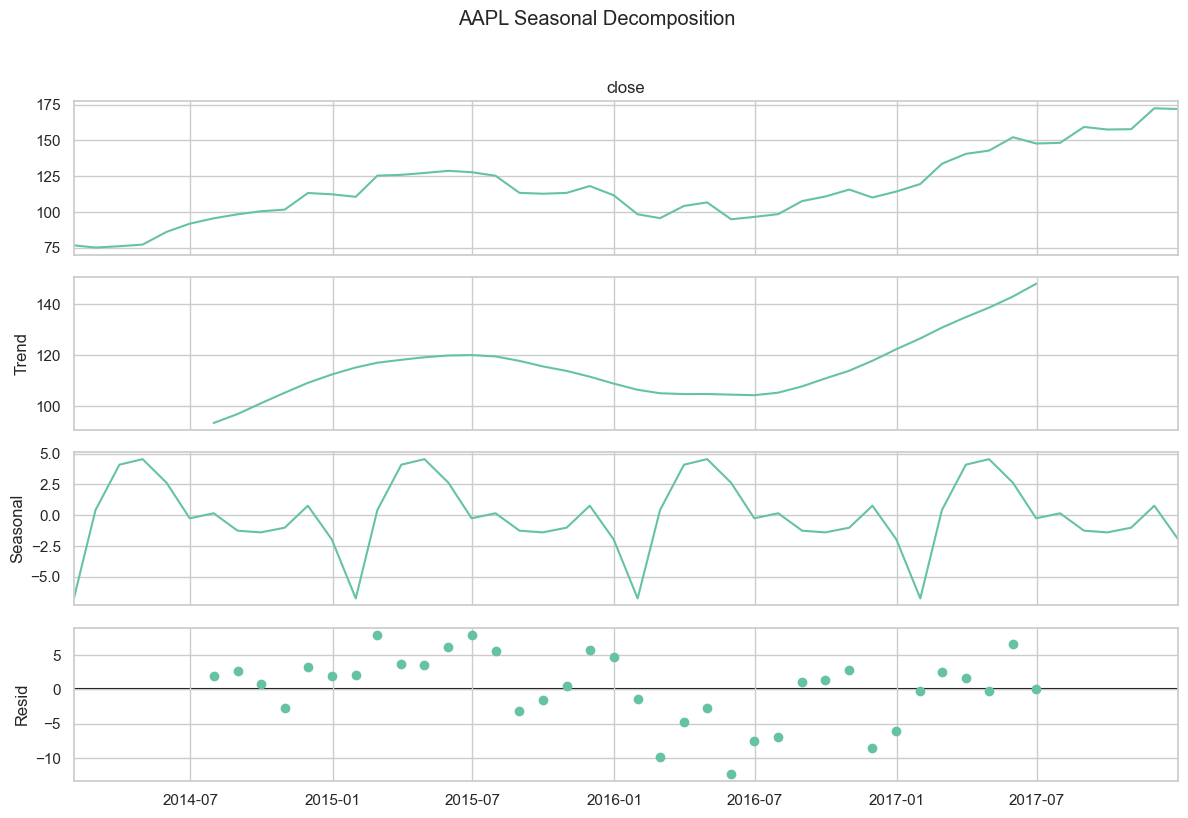

In [8]:
# Decompose the monthly series into trend, seasonal, and residual components.
decomposition = seasonal_decompose(aapl_monthly, model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.suptitle("AAPL Seasonal Decomposition", y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "aapl_seasonal_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 3: K-Means Clustering Analysis

In [9]:
# Load the Iris dataset for clustering. Labels are kept only for interpretation, not training.
iris = pd.read_csv(DATA_DIR / "iris.csv")
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X_iris = iris[features]

# Standardize the numerical features before K-Means.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


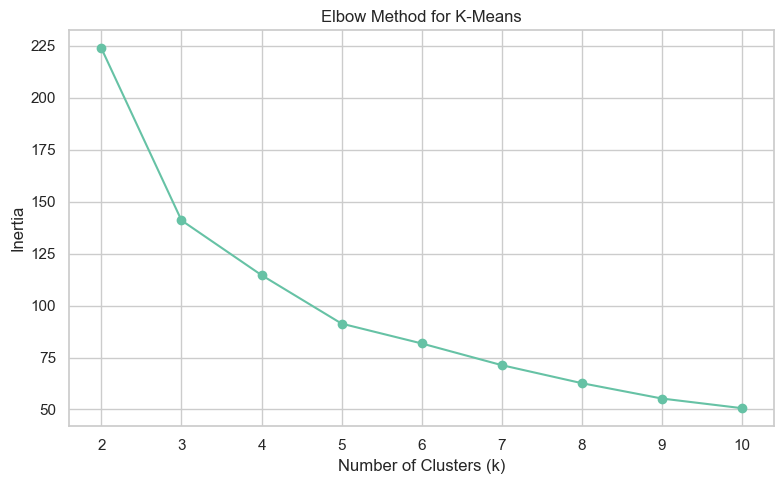

,k,inertia,silhouette
0,2,223.732006,0.580184
1,3,140.965817,0.458972
2,4,114.617886,0.385285
3,5,91.295445,0.347265
4,6,81.756582,0.340650
5,7,71.319821,0.328832
6,8,62.651767,0.340365
7,9,55.261841,0.342722
8,10,50.623169,0.340376


In [10]:
# Elbow method: compare inertia values for different numbers of clusters.
inertias = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), inertias, marker="o")
ax.set_title("Elbow Method for K-Means")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "kmeans_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({"k": list(k_values), "inertia": inertias, "silhouette": silhouette_scores})

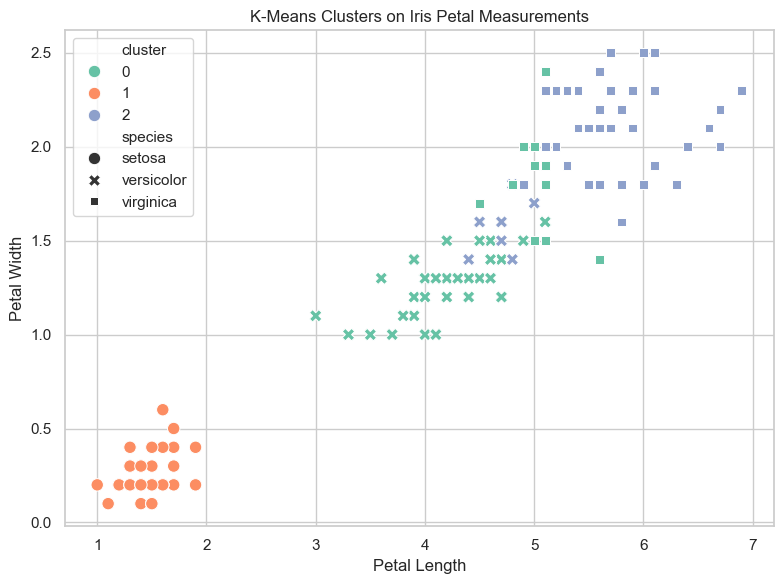

In [11]:
# The Iris dataset naturally has 3 species, and the elbow also supports k=3.
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
iris["cluster"] = kmeans_final.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=iris, x="petal_length", y="petal_width",
    hue="cluster", style="species", palette="Set2", s=80, ax=ax
)
ax.set_title("K-Means Clusters on Iris Petal Measurements")
ax.set_xlabel("Petal Length")
ax.set_ylabel("Petal Width")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "kmeans_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Compare learned clusters with actual species for interpretation.
pd.crosstab(iris["species"], iris["cluster"], rownames=["Actual Species"], colnames=["Cluster"])

Cluster,0,1,2
Actual Species,,,
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


## Level 2 Findings

- Average rooms (`RM`) has a positive relationship with house value (`MEDV`).
- AAPL monthly closing prices show a visible trend over the 2014-2017 period; moving averages smooth short-term fluctuations.
- K-Means with `k=3` produces interpretable Iris clusters that largely align with known species.